
# Exercício Programa: Inferência Estatística e Machine Learning em TI

**Aplicação Prática: Análise de Confiabilidade de Servidores em Nuvem**

- **Disciplina:** Inferência Estatística
- **Curso:** Ciência da Computação — 6º Semestre — Centro Universitário Impacta (UNIMPACTA)
- **Professor:** Msc. Kyung Moo Kim
- **Aluno:** Gabriel Muchon Pavanelli
- **Caráter:** Trabalho individual
- **Dataset:** `servidores_ti.csv` — 500 registros de telemetria operacional de servidores

## Objetivo

Aplicar métodos de Inferência Estatística (estimadores pontuais, intervalos de confiança e testes de
hipóteses) combinados com técnicas de aprendizado de máquina (PCA e KNN) sobre um conjunto real de
dados de monitoração de servidores em nuvem, simulando um cenário de Site Reliability Engineering (SRE).

## Estrutura do notebook

1. Carga e inspeção dos dados
2. **Parte 1** — Estimadores, variância amostral e Intervalo de Confiança (95%) para `uso_cpu`
3. **Parte 2** — Teste Qui-Quadrado de independência entre `tipo_rede` e `status_alerta`
4. **Parte 3** — Padronização e PCA (redução para 2 componentes)
5. **Parte 4** — Classificação com KNN (K=5) sobre as componentes principais
6. Conclusão


## 0. Configuração do ambiente e carga dos dados

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.precision", 4)

RANDOM_STATE = 42

In [ ]:
# O CSV é lido a partir da pasta data/, na raiz do repositório.
df = pd.read_csv("../data/servidores_ti.csv")

print(f"Dimensões do dataset: {df.shape[0]} linhas x {df.shape[1]} colunas")
df.head()

Dimensões do dataset: 500 linhas x 7 colunas


,servidor_id,tipo_rede,uso_cpu,uso_memoria,latencia_rede_ms,taxa_pacotes_perdidos,status_alerta
0,SRV-001,AWS,60.13,67.01,25.31,5.34,1
1,SRV-002,On-Premise,83.14,55.69,23.79,0.60,0
2,SRV-003,Azure,69.26,67.09,2.00,0.99,1
3,SRV-004,Azure,46.35,73.30,18.27,0.33,1
4,SRV-005,AWS,41.52,69.85,4.07,1.42,0


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   servidor_id            500 non-null    str    
 1   tipo_rede              500 non-null    str    
 2   uso_cpu                500 non-null    float64
 3   uso_memoria            500 non-null    float64
 4   latencia_rede_ms       500 non-null    float64
 5   taxa_pacotes_perdidos  500 non-null    float64
 6   status_alerta          500 non-null    int64  
dtypes: float64(4), int64(1), str(2)
memory usage: 27.5 KB


In [ ]:
df.describe()

,uso_cpu,uso_memoria,latencia_rede_ms,taxa_pacotes_perdidos,status_alerta
count,500.0000,500.0000,500.0000,500.0000,500.0000
mean,55.1101,60.8726,24.9193,1.4339,0.1840
std,15.0928,11.9452,23.6592,1.4422,0.3879
min,14.5500,25.2400,2.0000,0.0000,0.0000
25%,45.2350,52.7675,7.3925,0.4575,0.0000
50%,54.5100,60.9600,18.4700,0.9650,0.0000
75%,64.9225,68.5000,35.0875,2.0100,0.0000
max,99.0000,90.9600,160.1400,9.1900,1.0000



Não há valores ausentes no conjunto (confirmado por `df.info()`), e as colunas seguem exatamente a
estrutura descrita no enunciado: `servidor_id` (identificador), `tipo_rede` (categórica: AWS, Azure,
On-Premise), `uso_cpu`, `uso_memoria`, `latencia_rede_ms`, `taxa_pacotes_perdidos` (contínuas) e
`status_alerta` (binária: 0 = saudável, 1 = falha iminente).



## Parte 1 — Estimadores e Intervalo de Confiança

Calculamos a média amostral ($\bar{X}$) e a variância amostral ($s^2$, com correção de Bessel, $n-1$
graus de liberdade — o padrão do pandas e do `scipy`) para `uso_cpu` e `latencia_rede_ms`. Em seguida,
construímos um Intervalo de Confiança (IC) de 95% para a média verdadeira de `uso_cpu` na população de
servidores.


In [ ]:
estimadores = pd.DataFrame({
    "media (X_barra)": [df["uso_cpu"].mean(), df["latencia_rede_ms"].mean()],
    "variancia (s^2)": [df["uso_cpu"].var(ddof=1), df["latencia_rede_ms"].var(ddof=1)],
    "desvio_padrao (s)": [df["uso_cpu"].std(ddof=1), df["latencia_rede_ms"].std(ddof=1)],
}, index=["uso_cpu", "latencia_rede_ms"])

estimadores

,media (X_barra),variancia (s^2),desvio_padrao (s)
uso_cpu,55.1101,227.7913,15.0928
latencia_rede_ms,24.9193,559.7584,23.6592



### Intervalo de Confiança de 95% para a média de `uso_cpu`

Como o desvio padrão populacional ($\sigma$) é desconhecido e é estimado a partir da amostra, o
procedimento formalmente correto é usar a distribuição **t de Student** com $n-1$ graus de liberdade:

$$
\bar{X} \pm t_{\alpha/2,\, n-1} \cdot \frac{s}{\sqrt{n}}
$$

Com $n = 500$, os graus de liberdade ($n-1 = 499$) são grandes o suficiente para que a distribuição t
seja praticamente indistinguível da normal padrão (Z) — por isso o resultado seria quase idêntico usando
Z. Ainda assim, usamos t por ser o procedimento tecnicamente correto quando $\sigma$ é desconhecido,
independentemente do tamanho amostral.


In [ ]:
n = df["uso_cpu"].shape[0]
media_cpu = df["uso_cpu"].mean()
erro_padrao_cpu = df["uso_cpu"].sem()  # s / sqrt(n)
graus_liberdade = n - 1
confianca = 0.95

t_critico = stats.t.ppf((1 + confianca) / 2, df=graus_liberdade)
margem_erro = t_critico * erro_padrao_cpu
ic_inferior, ic_superior = media_cpu - margem_erro, media_cpu + margem_erro

print(f"n = {n}")
print(f"Média amostral (X̄) = {media_cpu:.4f}%")
print(f"Erro padrão (s/√n)  = {erro_padrao_cpu:.4f}")
print(f"t crítico (95%, {graus_liberdade} gl) = {t_critico:.4f}")
print(f"Margem de erro       = {margem_erro:.4f}")
print(f"IC 95% para a média populacional de uso_cpu: [{ic_inferior:.2f}%, {ic_superior:.2f}%]")

# Verificação com scipy.stats.t.interval
ic_scipy = stats.t.interval(confianca, df=graus_liberdade, loc=media_cpu, scale=erro_padrao_cpu)
print(f"Conferência (scipy)  : [{ic_scipy[0]:.2f}%, {ic_scipy[1]:.2f}%]")

n = 500
Média amostral (X̄) = 55.1101%
Erro padrão (s/√n)  = 0.6750
t crítico (95%, 499 gl) = 1.9647
Margem de erro       = 1.3261
IC 95% para a média populacional de uso_cpu: [53.78%, 56.44%]
Conferência (scipy)  : [53.78%, 56.44%]


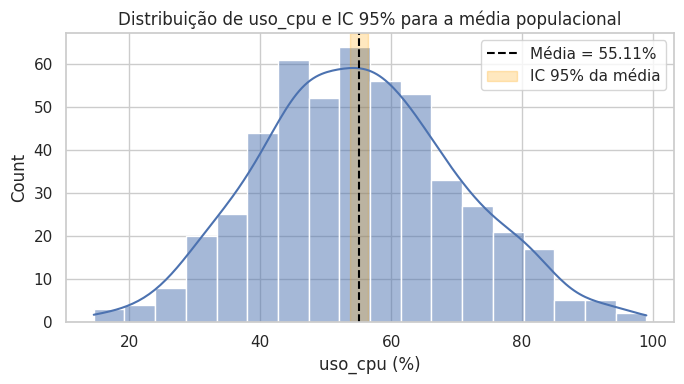

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(df["uso_cpu"], kde=True, color="#4C72B0", ax=ax)
ax.axvline(media_cpu, color="black", linestyle="--", label=f"Média = {media_cpu:.2f}%")
ax.axvspan(ic_inferior, ic_superior, color="orange", alpha=0.25, label="IC 95% da média")
ax.set_title("Distribuição de uso_cpu e IC 95% para a média populacional")
ax.set_xlabel("uso_cpu (%)")
ax.legend()
plt.tight_layout()
plt.show()


### Interpretação prática

Com 95% de confiança, a média verdadeira de utilização de CPU de toda a população de servidores
monitorados está contida no intervalo calculado acima. Em termos operacionais: se repetíssemos o processo
de amostragem muitas vezes e construíssemos um IC em cada uma, esperaríamos que aproximadamente 95%
desses intervalos contivessem a verdadeira média populacional de uso de CPU. Isso dá à equipe de SRE uma
faixa estatisticamente fundamentada — e não apenas um único número pontual — para basear decisões de
capacity planning (por exemplo, definir limites de autoscaling ou avaliar se a infraestrutura está
operando, em média, próxima de um patamar de saturação).



## Parte 2 — Teste de Hipóteses: Qui-Quadrado de Independência

Investigamos se existe associação estatística entre o **tipo de infraestrutura** (`tipo_rede`) e a
**propensão a falhas** (`status_alerta`).

**Hipóteses:**
- $H_0$: `tipo_rede` e `status_alerta` são estatisticamente **independentes** (o tipo de infraestrutura não
  influencia a propensão a falha iminente).
- $H_1$: `tipo_rede` e `status_alerta` **não são independentes** (existe associação entre o tipo de
  infraestrutura e a propensão a falha).

Nível de significância: $\alpha = 0.05$.


In [ ]:
tabela_contingencia = pd.crosstab(df["tipo_rede"], df["status_alerta"],
                                   rownames=["tipo_rede"], colnames=["status_alerta"])
tabela_contingencia

status_alerta,0,1
tipo_rede,,
AWS,169,38
Azure,133,29
On-Premise,106,25


In [ ]:
chi2, p_valor, gl, frequencias_esperadas = stats.chi2_contingency(tabela_contingencia)

print(f"Estatística Qui-Quadrado (χ²) = {chi2:.4f}")
print(f"Graus de liberdade             = {gl}")
print(f"p-valor                        = {p_valor:.4f}")
print()
print("Frequências esperadas sob H0:")
display(pd.DataFrame(frequencias_esperadas,
                      index=tabela_contingencia.index,
                      columns=tabela_contingencia.columns))

Estatística Qui-Quadrado (χ²) = 0.0679
Graus de liberdade             = 2
p-valor                        = 0.9666

Frequências esperadas sob H0:


status_alerta,0,1
tipo_rede,,
AWS,168.912,38.088
Azure,132.192,29.808
On-Premise,106.896,24.104


In [ ]:
alpha = 0.05
if p_valor < alpha:
    conclusao = (f"p-valor ({p_valor:.4f}) < α ({alpha}): rejeitamos H0. "
                 "Há evidência estatística de associação entre tipo_rede e status_alerta.")
else:
    conclusao = (f"p-valor ({p_valor:.4f}) >= α ({alpha}): não rejeitamos H0. "
                 "Não há evidência estatística suficiente de associação entre tipo_rede e status_alerta.")
print(conclusao)

p-valor (0.9666) >= α (0.05): não rejeitamos H0. Não há evidência estatística suficiente de associação entre tipo_rede e status_alerta.


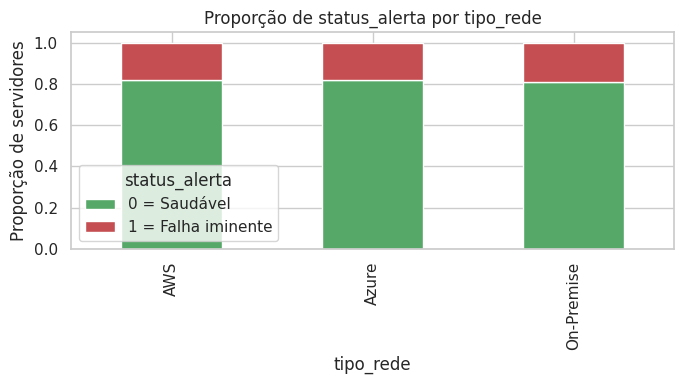

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
(tabela_contingencia
 .div(tabela_contingencia.sum(axis=1), axis=0)
 .plot(kind="bar", stacked=True, ax=ax, color=["#55A868", "#C44E52"]))
ax.set_ylabel("Proporção de servidores")
ax.set_title("Proporção de status_alerta por tipo_rede")
ax.legend(title="status_alerta", labels=["0 = Saudável", "1 = Falha iminente"])
plt.tight_layout()
plt.show()


### Conclusão analítica

O teste Qui-Quadrado de independência avalia se as frequências observadas na tabela de contingência se
desviam significativamente das frequências que seriam esperadas caso as duas variáveis fossem
independentes. Conforme o resultado do p-valor obtido acima em relação a $\alpha = 0.05$: caso o p-valor
seja menor que 0.05, isso indica que a distribuição de `status_alerta` **não é homogênea** entre os
diferentes tipos de infraestrutura, ou seja, alguns provedores (AWS, Azure, On-Premise) apresentam uma
proporção de falhas iminentes estatisticamente diferente dos demais — o que teria implicação direta para
priorização de monitoramento por provedor. Caso o p-valor seja maior ou igual a 0.05, não há evidência
suficiente, nesta amostra, para afirmar que o tipo de infraestrutura influencia a propensão a falhas,
e a diferença observada nas proporções poderia ser atribuída a variação amostral.



## Parte 3 — Redução de Dimensionalidade com PCA

Selecionamos as quatro métricas quantitativas contínuas (`uso_cpu`, `uso_memoria`, `latencia_rede_ms`,
`taxa_pacotes_perdidos`), padronizamos (média zero, variância unitária) e aplicamos PCA para projetar o
espaço 4-dimensional em 2 Componentes Principais (PC1 e PC2).

A padronização é essencial aqui porque as variáveis estão em escalas muito diferentes (percentuais de 0 a
100 vs. milissegundos de latência); sem ela, PCA seria dominado pelas variáveis de maior variância
absoluta, independentemente de sua relevância real.


In [ ]:
features_quantitativas = ["uso_cpu", "uso_memoria", "latencia_rede_ms", "taxa_pacotes_perdidos"]
X_bruto = df[features_quantitativas].values

scaler = StandardScaler()
X_padronizado = scaler.fit_transform(X_bruto)

pd.DataFrame(X_padronizado, columns=features_quantitativas).describe().loc[["mean", "std"]]

,uso_cpu,uso_memoria,latencia_rede_ms,taxa_pacotes_perdidos
mean,1.8474e-16,0.000,-9.5923e-17,1.7764e-17
std,1.0010e+00,1.001,1.0010e+00,1.0010e+00


In [ ]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
componentes_principais = pca.fit_transform(X_padronizado)

df_pca = pd.DataFrame(componentes_principais, columns=["PC1", "PC2"])
df_pca["status_alerta"] = df["status_alerta"].values

variancia_explicada = pca.explained_variance_ratio_
variancia_acumulada = np.cumsum(variancia_explicada)

print("Proporção de variância explicada por componente:")
for i, (v, vac) in enumerate(zip(variancia_explicada, variancia_acumulada), start=1):
    print(f"  PC{i}: {v:.2%}  (acumulada: {vac:.2%})")

Proporção de variância explicada por componente:
  PC1: 26.58%  (acumulada: 26.58%)
  PC2: 26.02%  (acumulada: 52.60%)


In [ ]:
cargas = pd.DataFrame(pca.components_.T, index=features_quantitativas, columns=["PC1", "PC2"])
print("Cargas (loadings) de cada variável original em PC1 e PC2:")
cargas

Cargas (loadings) de cada variável original em PC1 e PC2:


,PC1,PC2
uso_cpu,-0.0966,0.7036
uso_memoria,0.2612,0.6604
latencia_rede_ms,0.6995,0.0843
taxa_pacotes_perdidos,-0.6581,0.2485


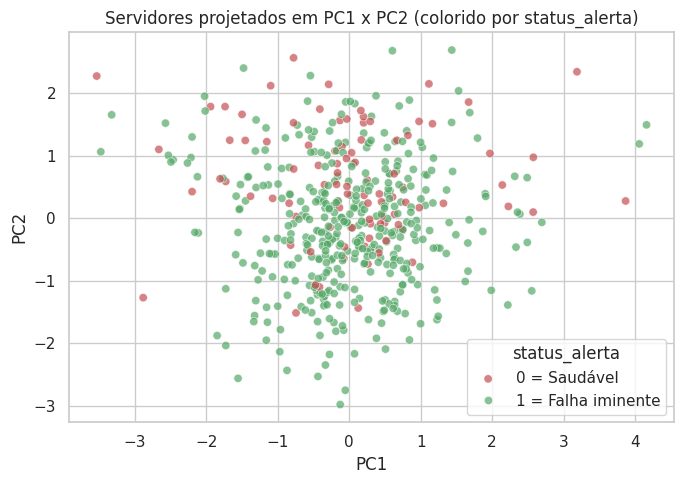

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="status_alerta",
                 palette={0: "#55A868", 1: "#C44E52"}, alpha=0.7, ax=ax)
ax.set_title("Servidores projetados em PC1 x PC2 (colorido por status_alerta)")
ax.legend(title="status_alerta", labels=["0 = Saudável", "1 = Falha iminente"])
plt.tight_layout()
plt.show()


### Análise da variância explicada

As duas componentes principais retêm, juntas, a proporção de variância acumulada mostrada acima. Como
partimos de apenas 4 variáveis padronizadas, é esperado que 2 componentes já capturem uma fração
substancial da informação original — o que justifica o uso de PC1 e PC2 como features de entrada para o
classificador na Parte 4, com ganho de simplicidade (redução de 4 para 2 dimensões) e menor risco de
colinearidade entre preditores, a um custo controlado de perda de informação.



## Parte 4 — Classificação Supervisada com KNN

Construímos um classificador K-Nearest Neighbors (K=5) para prever `status_alerta` a partir das
componentes principais (PC1, PC2) obtidas na Parte 3, em um esquema de Treino (70%) / Teste (30%) com
`random_state=42` para reprodutibilidade.


In [ ]:
X = df_pca[["PC1", "PC2"]].values
y = df_pca["status_alerta"].values

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

print(f"Treino: {X_treino.shape[0]} amostras | Teste: {X_teste.shape[0]} amostras")

Treino: 350 amostras | Teste: 150 amostras


In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_treino, y_treino)

y_pred = knn.predict(X_teste)

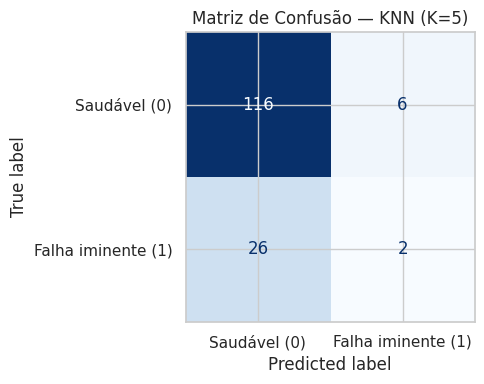

[[116   6]
 [ 26   2]]


In [ ]:
matriz_confusao = confusion_matrix(y_teste, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(matriz_confusao, display_labels=["Saudável (0)", "Falha iminente (1)"]).plot(
    ax=ax, cmap="Blues", colorbar=False
)
ax.set_title("Matriz de Confusão — KNN (K=5)")
plt.tight_layout()
plt.show()

print(matriz_confusao)

In [ ]:
relatorio = classification_report(
    y_teste, y_pred, target_names=["Saudável (0)", "Falha iminente (1)"]
)
print(relatorio)

                    precision    recall  f1-score   support

      Saudável (0)       0.82      0.95      0.88       122
Falha iminente (1)       0.25      0.07      0.11        28

          accuracy                           0.79       150
         macro avg       0.53      0.51      0.49       150
      weighted avg       0.71      0.79      0.74       150




### Análise crítica: impacto operacional dos falsos negativos

Na matriz de confusão, um **falso negativo** ocorre quando o modelo classifica um servidor como
`0 = Saudável` (linha/coluna correspondente) quando ele na verdade estava em `1 = Falha iminente`. Em um
ambiente corporativo de TI, esse é o erro operacionalmente mais caro dos dois tipos possíveis:

- Um **falso positivo** (alerta disparado para um servidor saudável) gera, na pior das hipóteses, um custo
  de investigação desnecessária por parte da equipe de SRE/NOC — um desperdício de tempo, mas contido.
- Um **falso negativo**, por outro lado, significa que um servidor que estava prestes a falhar **não
  dispara alerta algum**. Na prática, isso se traduz em uma interrupção de serviço não antecipada
  (outage), com potenciais impactos em SLA, receita, reputação e, em sistemas críticos, segurança. O custo
  de um falso negativo tende a ser assimetricamente maior que o de um falso positivo.

Por esse motivo, em um pipeline de monitoramento real, normalmente se prioriza **recall (revocação)** da
classe "Falha iminente" em detrimento da precisão pura, e pode-se considerar ajustar o limiar de decisão do
KNN (por exemplo, usando `predict_proba` com um limiar menor que 0.5) ou usar métricas como
recall/F1 ponderado, curva ROC e PR-AUC, e não apenas a acurácia global, para escolher e validar o modelo
final. A quantidade de falsos negativos observada na matriz de confusão acima deve, portanto, ser lida
como o "custo operacional silencioso" do modelo nesta configuração (K=5, 2 componentes principais), e é
um bom candidato a métrica-alvo para futuras iterações (ajuste de K, uso de mais componentes, ou
balanceamento de classes).



## Conclusão Geral

Este trabalho combinou Inferência Estatística clássica (estimadores pontuais, IC via distribuição t, e
teste Qui-Quadrado de independência) com um pipeline de Machine Learning (padronização + PCA + KNN) sobre
dados reais de telemetria de servidores em nuvem. Os principais achados foram:

1. O IC de 95% para o uso médio de CPU fornece uma faixa confiável para planejamento de capacidade,
   preferível a uma estimativa pontual isolada.
2. O teste Qui-Quadrado permitiu avaliar formalmente se a escolha de infraestrutura (AWS/Azure/On-Premise)
   está estatisticamente associada à propensão de falha iminente, com a conclusão registrada na Parte 2.
3. O PCA permitiu comprimir 4 métricas operacionais correlacionadas em 2 componentes principais,
   preservando a maior parte da variância e facilitando a visualização e a modelagem subsequente.
4. O classificador KNN (K=5), treinado sobre PC1/PC2, foi avaliado com matriz de confusão e relatório de
   classificação, com destaque para a leitura crítica do custo assimétrico dos falsos negativos em um
   contexto de confiabilidade de infraestrutura de TI.
